In [6]:
import os
import wfdb
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

In [7]:
'''
supin_transition = [
    'Conclude slow tilt down',
    'Transition back to supine',
    'End slow tilt down',
    'End fast tilt down',
    'Back to supine',
    'End rapid tilt down',
    'Conclusion of rapid tilt down',
    'Conclude rapid tilt down',
    'Conclusion of slow tilt down',
    'Conclusion of slow tilt down',
    'Conclusion of rapid tilt dow',
    'Transition back to supin',
    'Conclude slow tilt dow',
    'Conslusion of slow tilt down',
    '   Conclusion of slow tilt down','Conslusion of slow tilt down'
]
'''

supin_transition = [
    'Transition back to supine',
    'Back to supine',
    'Transition back to supin'
]

stand_up_transition = [
    'Stand up','Stand-up from supine','0 -1 0 \tStand up','Stand-up']

In [8]:
CURRENT_PATH = os.getcwd()
ID_TILT_TEST_PATH = '/Users/alessiorizzi/Desktop/env_tesi/dataset/supin_stand/RECORDS.txt'
DATA_DIR = '/Users/alessiorizzi/Desktop/env_tesi/dataset/supin_stand/'

with open (ID_TILT_TEST_PATH) as file:
  id_pazienti = file.readlines()

id_pazienti = [x.strip() for x in id_pazienti]

In [9]:
patien_dict = {id_p: [] for id_p in id_pazienti}

for id_p in id_pazienti:

  record_full_path = os.path.join(DATA_DIR, id_p)
  record = wfdb.rdrecord(record_full_path)
  annotation = wfdb.rdann(record_full_path, 'anI')

  signal_250Hz = record.p_signal[:, 1]      # Il segnale ECG vero e proprio (matrice numpy)
  fs = record.fs                            # Frequenza di campionamento 250
  leads = record.sig_name                   # ['ABP', 'ECG', 'Angle']


  signal_100Hz = signal.resample_poly(signal_250Hz, up=2, down=5)
  transition = annotation.aux_note          # nomi delle transizioni
  samples = np.array(np.round(annotation.sample / 2.5).astype(int), dtype='int') # numero di sample per ECG

  for i, (name_tr, sample) in enumerate(zip(transition, samples)):

    # 1. Viene identificata la label (0, 1 o None se non ci interessa)
    if name_tr in supin_transition:
        label = 0
    elif name_tr in stand_up_transition:
        label = 1
    else:
        continue  # Salta le transizioni che non sono nelle due liste

    # 2. Se siamo all'ultimo indice, prendiamo dal sample attuale fino alla fine
    if i == len(transition) - 1:
        ecg = signal_100Hz[sample:]
    else:
      # Altrimenti prendiamo dall'inizio (0) o dal sample precedente fino a quello attuale
      start = 0 if i == 0 else samples[i - 1]
      ecg = signal_100Hz[start:sample]

    # 3. Aggiunta al dizionario
    if len(ecg) > 344:
      patien_dict[id_p].append((ecg, label))

In [10]:
nuovo_dict = {}
chunk_size = 344

for paziente_id, registrazioni in patien_dict.items():
    nuovo_dict[paziente_id] = []

    for ecg_array, label in registrazioni:
        # Calcoliamo quanti blocchi da 1000 possiamo estrarre
        n_chunks = len(ecg_array) // chunk_size

        for i in range(n_chunks):
            start = i * chunk_size
            end = start + chunk_size

            # Estraiamo il segmento
            segmento = ecg_array[start:end]

            # Aggiungiamo alla lista del paziente come tupla (segmento, label)
            nuovo_dict[paziente_id].append((segmento, label))


In [11]:
ORIGINAL_ECG_DIR = '/Users/alessiorizzi/Desktop/env_tesi/img/tot_ecg'

if not os.path.exists(ORIGINAL_ECG_DIR):
    os.makedirs(ORIGINAL_ECG_DIR)

for paziente_id, segmenti in nuovo_dict.items():

    # 1. Crea la cartella del paziente
    path_paziente = os.path.join(ORIGINAL_ECG_DIR, paziente_id)

    # 2. Crea le sottocartelle 0 e 1 per le label
    for label_dir in ['0', '1']:
        os.makedirs(os.path.join(path_paziente, label_dir), exist_ok=True)

    print(f"Elaborazione Paziente {paziente_id}...")

    for idx, (ecg_array, label) in enumerate(segmenti):
        # Definiamo il percorso finale: dataset_ecg_visual/ID/LABEL/IDX.png
        nome_file = f"{idx}.png"
        path_salvataggio = os.path.join(path_paziente, str(label), nome_file)

        # 3. Generazione del grafico
        plt.figure(figsize=(10, 4))
        plt.plot(ecg_array, color='blue', linewidth=0.5)

        # 4. Salvataggio
        plt.savefig(path_salvataggio, bbox_inches='tight', pad_inches=0)
        plt.close()  # Chiude la figura per liberare memoria RAM

print("Salvataggio completato!")

Elaborazione Paziente 12726...
Elaborazione Paziente 12734...
Elaborazione Paziente 12744...
Elaborazione Paziente 12754...
Elaborazione Paziente 12755...
Elaborazione Paziente 12814...
Elaborazione Paziente 12815...
Elaborazione Paziente 12819...
Elaborazione Paziente 12821...
Elaborazione Paziente 13960...
Salvataggio completato!


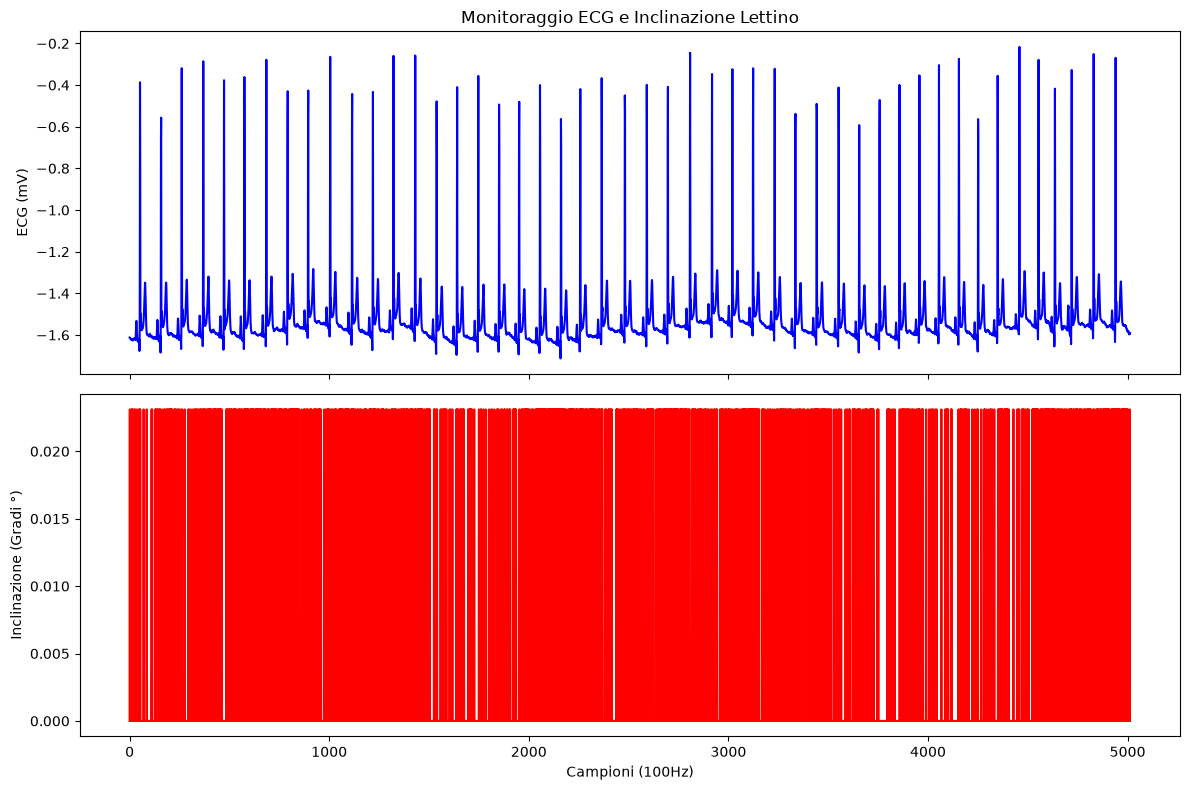

In [12]:
import matplotlib.pyplot as plt

# Carica i segnali
# p_signal[:, 0] -> ECG
# p_signal[:, 1] -> Gradi del lettino (se presente come canale)
ecg_signal = record.p_signal[:, 1]
tilt_angle = record.p_signal[:, 2] # misurazione in gradi del lettino

# Se hai fatto il resample a 100Hz per l'ECG,
# devi farlo identico anche per il segnale dell'inclinazione!

# Visualizzazione
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Grafico ECG
ax1.plot(signal_100Hz[58828:63841], color='blue')
ax1.set_ylabel('ECG (mV)')
ax1.set_title('Monitoraggio ECG e Inclinazione Lettino')

# Grafico Inclinazione
ax2.plot(tilt_angle[58828:63841], color='red')
ax2.set_ylabel('Inclinazione (Gradi °)')
ax2.set_xlabel('Campioni (100Hz)')

plt.tight_layout()
plt.show()

In [13]:
from pathlib import Path

PATH = '/Users/alessiorizzi/Desktop/env_tesi/img/filtrati_ecg'
percorso = Path(PATH)
labels = ['0', '1']

test_dict = {}

for key in nuovo_dict.keys():

    indici_paziente = []

    for label in labels:
        PATH_COMPLETO = percorso / key / label
        if PATH_COMPLETO.exists():
            # Prendiamo gli indici dei file presenti nella cartella di QUESTO paziente
            nomi_file = [int(f.name.split('.png')[0]) for f in PATH_COMPLETO.iterdir() if f.is_file()]
            indici_paziente.extend(nomi_file)

    # Trasformiamo in set per velocità di ricerca
    set_indici = set(indici_paziente)

    # --- FILTRAGGIO IMMEDIATO per questo paziente ---
    # Prendiamo i dati da nuovo_dict[key] solo se l'indice i esiste tra i file PNG
    dati_originali = nuovo_dict[key]
    test_dict[key] = [dati_originali[i] for i in range(len(dati_originali)) if i in set_indici]

    print(f"Paziente {key}: trovati {len(indici_paziente)} file, filtrati {len(test_dict[key])} elementi.")

# A questo punto test_dict è il tuo nuovo dizionario filtrato correttamente

Paziente 12726: trovati 218 file, filtrati 218 elementi.
Paziente 12734: trovati 286 file, filtrati 286 elementi.
Paziente 12744: trovati 279 file, filtrati 279 elementi.
Paziente 12754: trovati 279 file, filtrati 279 elementi.
Paziente 12755: trovati 271 file, filtrati 271 elementi.
Paziente 12814: trovati 287 file, filtrati 287 elementi.
Paziente 12815: trovati 360 file, filtrati 360 elementi.
Paziente 12819: trovati 347 file, filtrati 347 elementi.
Paziente 12821: trovati 301 file, filtrati 301 elementi.
Paziente 13960: trovati 285 file, filtrati 285 elementi.


In [14]:
def z_score(X, mean=None, std=None):
    # se non passiamo mean e std li calcoliamo, caso X_train
    if mean is None or std is None:
        mean = np.mean(X)
        std = np.std(X)

    X_normalized = (X - mean) / (std + 1e-7)

    return X_normalized, mean, std


# Fine-Tuning linear decay
def linear_decay_end(epoch):

    initial_lr = 1e-3   # inizialmente era 1e-2 (+1)
    final_lr = 1e-5     # inizialmente era 1e-4 (-1)
    epochs = 100

    # Formula del decadimento lineare
    lr = initial_lr - (initial_lr - final_lr) * (epoch / epochs)

    return float(lr)

In [15]:

import tensorflow as tf
from tensorflow.keras import layers

import seaborn as sns
from sklearn.metrics import confusion_matrix

def augment_ecg(batch_x, batch_y):
    """
    Applica Gaussian Noise e Amplitude Scaling on-the-fly.
    batch_x shape: (batch_size, 344, 1)
    """

    # 1. AMPLITUDE SCALING [0.7, 1.3]
    # Generiamo un fattore casuale per ogni elemento del batch
    alpha = tf.random.uniform(shape=[tf.shape(batch_x)[0], 1, 1], minval=0.7, maxval=1.3)
    batch_x = batch_x * alpha

    # 2. GAUSSIAN NOISE (std dev in [0.01, 0.1])
    # Scegliamo una deviazione standard casuale per il rumore
    std_dev = tf.random.uniform(shape=[], minval=0.01, maxval=0.1)
    noise = tf.random.normal(shape=tf.shape(batch_x), mean=0.0, stddev=std_dev)
    batch_x = batch_x + noise

    # Nota sul Time Stretching:
    # Scalare temporalmente un segnale fisso a 344 campioni è complesso on-the-fly
    # perché cambierebbe la lunghezza. Di solito per i battiti centrati ci si
    # ferma a Noise e Amplitude, che sono i più efficaci.

    return batch_x, batch_y


def model_ptbxl(input_shape=(344, 1)):

    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(1, 1, kernel_initializer='ones', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)

    filters = [16, 16, 32, 32, 64, 64]
    kernels = [5, 5, 5, 3, 3, 3]

    # Temporal Fusion
    for i, (f, k) in enumerate(zip(filters, kernels)):
        x = layers.Conv1D(f, k, dilation_rate=2, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU()(x)
        x = layers.MaxPooling1D(2)(x)

    # Inter-lead Fusion
    x = layers.Conv1D(128, 1, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU()(x)
    # x = layers.Dropout(0.4)(x) # Protezione finale prima dell'output

    x = layers.Flatten()(x)
    #outputs = layers.Dense(5, activation='sigmoid')(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)

    return model

def linear_decay(epoch):

    initial_lr = 1e-2   # inizialmente era 1e-2 (+1)
    final_lr = 1e-4     # inizialmente era 1e-4 (-1)
    epochs = 200

    # Formula del decadimento lineare
    lr = initial_lr - (initial_lr - final_lr) * (epoch / epochs)

    return float(lr)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

ECG_CM = '/Users/alessiorizzi/Desktop/env_tesi/img/confusion_matrix'

if not os.path.exists(ECG_CM):
    os.makedirs(ECG_CM)


keys = list(test_dict.keys())

for fold in range(len(keys)):
  X_test_temp, y_test_temp = [], []
  X_train_temp, y_train_temp = [], []

  key_test = [keys[fold]]
  keys_train = [x for j, x in enumerate(keys) if j != fold]

  X_train_dict = {k: test_dict[k] for k in keys_train}
  X_test_dict  = {k: test_dict[k] for k in key_test}

  for key, value in X_test_dict.items():
    for ecg, label in value:
      X_test_temp.append(ecg)
      y_test_temp.append(label)

  X_test_temp = np.array(X_test_temp, dtype='float32')
  y_test = np.array(y_test_temp)

  for key, value in X_train_dict.items():
    for ecg, label in value:
      X_train_temp.append(ecg)
      y_train_temp.append(label)

  X_train_temp = np.array(X_train_temp,dtype='float32')
  y_train = np.array(y_train_temp)

  X_train, mean, std = z_score(X_train_temp)
  X_test, _, _ = z_score(X_test_temp, mean, std)

  X_train = np.expand_dims(X_train, axis=-1)
  X_test = np.expand_dims(X_test, axis=-1)


  print(f"X_train: {X_train.shape}")
  print(f"X_test: {X_test.shape}")

  # Creazione del Dataset
  train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

  # Pipeline: Shuffle -> Batch -> Augment
  train_ds = (train_ds
              .shuffle(buffer_size=X_train.shape[0])
              .batch(64) # o il tuo batch_size preferito
              .map(augment_ecg, num_parallel_calls=tf.data.AUTOTUNE)
              .prefetch(tf.data.AUTOTUNE))

  # Dataset di validazione (SENZA augmentation!)
  val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

  optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2) # Il valore iniziale
  lr_scheduler = tf.keras.callbacks.LearningRateScheduler(linear_decay)

  model = model_ptbxl()

  model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

 # Definizione dei percorsi per il salvataggio del modello temporaneo del fold
  checkpoint_path = f"best_model_fold_{fold}.h5"

  # Callback 1: Early Stopping
  # Interrompe se la val_loss non migliora per 10 epoche (patience)
  early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

  # Callback 2: Model Checkpoint
  # Salva solo il modello che ha ottenuto la miglior val_loss finora
  checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                               monitor='val_loss',
                               save_best_only=True,
                               verbose=1)

  # Aggiungi i callback a model.fit
  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=100,
      callbacks=[lr_scheduler, early_stop, checkpoint]
  )

  # --- CALCOLO CONFUSION MATRIX CON IL MIGLIOR MODELLO ---

  # Carichiamo il modello migliore salvato dal checkpoint
  # (Anche se restore_best_weights=True lo fa in memoria, ricaricare dal file è più sicuro)
  best_model = tf.keras.models.load_model(checkpoint_path)

  # Eseguiamo la predizione sul set di test del fold
  y_pred_probs = best_model.predict(X_test)
  y_pred = (y_pred_probs > 0.5).astype(int)

  # Calcolo Matrice di Confusione
  cm = confusion_matrix(y_test, y_pred)

  # Plot e Salvataggio (come visto prima)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Supin', 'Stand-up'],
              yticklabels=['Supin', 'Stand-up'])
  plt.title(f'Confusion Matrix (Best Model) - Fold {fold}')
  plt.ylabel('Reale')
  plt.xlabel('Predetto')

  save_path = os.path.join(ECG_CM, f'confusion_matrix_fold_{fold}.png')
  plt.savefig(save_path)
  plt.close()

  # Opzionale: Rimuovi il file .h5 per non intasare lo spazio disco
  os.remove(checkpoint_path)

  print(f"Matrice di confusione salvata per il fold {fold} in: {save_path}")



X_train: (2695, 344, 1)
X_test: (218, 344, 1)
Epoch 1/100


/Users/alessiorizzi/Desktop/env_tesi/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


38/43 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6637 - loss: 0.6867
Epoch 1: val_loss improved from None to 0.68043, saving model to best_model_fold_0.h5



Epoch 1: finished saving model to best_model_fold_0.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6768 - loss: 0.6627 - val_accuracy: 0.6651 - val_loss: 0.6804 - learning_rate: 0.0100
Epoch 2/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7774 - loss: 0.4498
Epoch 2: val_loss improved from 0.68043 to 0.64513, saving model to best_model_fold_0.h5



Epoch 2: finished saving model to best_model_fold_0.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7755 - loss: 0.4529 - val_accuracy: 0.7294 - val_loss: 0.6451 - learning_rate: 0.0100
Epoch 3/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8164 - loss: 0.4043
Epoch 3: val_loss improved from 0.64513 to 0.27392, saving model to best_model_fold_0.h5


...

/Users/alessiorizzi/Desktop/env_tesi/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6593 - loss: 0.6442
Epoch 1: val_loss improved from None to 1.22033, saving model to best_model_fold_9.h5



Epoch 1: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.6591 - loss: 0.6442 - val_accuracy: 0.6281 - val_loss: 1.2203 - learning_rate: 0.0100
Epoch 2/100
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7430 - loss: 0.5106
Epoch 2: val_loss did not improve from 1.22033
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7447 - loss: 0.5057 - val_accuracy: 0.6281 - val_loss: 2.0708 - learning_rate: 0.0100
Epoch 3/100
38/42 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8014 - loss: 0.4157
Epoch 3: val_loss did not improve from 1.22033
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8010 - loss: 0.4113 - val_accuracy: 0.6281 - val_loss: 2.5698 - learning_rate: 0.0099
Epoch 4/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8132 - loss: 0.3980
Epoch 4: val_loss did not improve from 1.22033
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8132 - loss: 0.3980 - val_accuracy: 0.6281 - val_loss: 1.5143 - learnin


Epoch 7: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8676 - loss: 0.2985 - val_accuracy: 0.8772 - val_loss: 0.2804 - learning_rate: 0.0097
Epoch 8/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7668 - loss: 0.4891
Epoch 8: val_loss did not improve from 0.28043
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7671 - loss: 0.4885 - val_accuracy: 0.6281 - val_loss: 4.4294 - learning_rate: 0.0097
Epoch 9/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8773 - loss: 0.2799
Epoch 9: val_loss did not improve from 0.28043
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8771 - loss: 0.2807 - val_accuracy: 0.7614 - val_loss: 1.0818 - learning_rate: 0.0096
Epoch 10/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8710 - loss: 0.2997
Epoch 10: val_loss did not improve from 0.28043
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8710 - loss: 0.2997 - val_accuracy: 0.7439 - val_loss: 1.1218 - learn

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Matrice di confusione salvata per il fold 9 in: /Users/alessiorizzi/Desktop/env_tesi/img/confusion_matrix/confusion_matrix_fold_9.png


In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

ECG_CM = '/Users/alessiorizzi/Desktop/env_tesi/img/confusion_matrix/test_2'
MODEL_PRE_TRAINING = '/Users/alessiorizzi/Desktop/env_tesi/model/best_ptbxl_d1_model_NORM_vs_ALL_344.keras'
ECG_METRICHE = '/Users/alessiorizzi/Desktop/env_tesi/img/metriche/test_2'

if not os.path.exists(ECG_CM):
    os.makedirs(ECG_CM)

if not os.path.exists(ECG_METRICHE):
    os.makedirs(ECG_METRICHE)

keys = list(test_dict.keys())

for fold in range(len(keys)):
  X_test_temp, y_test_temp = [], []
  X_train_temp, y_train_temp = [], []

  key_test = [keys[fold]]
  keys_train = [x for j, x in enumerate(keys) if j != fold]

  X_train_dict = {k: test_dict[k] for k in keys_train}
  X_test_dict  = {k: test_dict[k] for k in key_test}

  for key, value in X_test_dict.items():
    for ecg, label in value:
      X_test_temp.append(ecg)
      y_test_temp.append(label)

  X_test_temp = np.array(X_test_temp, dtype='float32')
  y_test = np.array(y_test_temp)

  for key, value in X_train_dict.items():
    for ecg, label in value:
      X_train_temp.append(ecg)
      y_train_temp.append(label)

  X_train_temp = np.array(X_train_temp,dtype='float32')
  y_train = np.array(y_train_temp)

  X_train, mean, std = z_score(X_train_temp)
  X_test, _, _ = z_score(X_test_temp, mean, std)

  X_train = np.expand_dims(X_train, axis=-1)
  X_test = np.expand_dims(X_test, axis=-1)


  print(f"X_train: {X_train.shape}")
  print(f"X_test: {X_test.shape}")

  # Creazione del Dataset
  train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))

  # Pipeline: Shuffle -> Batch -> Augment
  train_ds = (train_ds
              .shuffle(buffer_size=X_train.shape[0])
              .batch(64) # o il tuo batch_size preferito
              .map(augment_ecg, num_parallel_calls=tf.data.AUTOTUNE)
              .prefetch(tf.data.AUTOTUNE))

  # Dataset di validazione (SENZA augmentation!)
  val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(64).prefetch(tf.data.AUTOTUNE)

  optimizer = tf.keras.optimizers.Adam(learning_rate=1e-10) # Il valore iniziale

  old_model = tf.keras.models.load_model(MODEL_PRE_TRAINING, compile=False)
  x = old_model.layers[-2].output

  # 3.
  new_outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

  # 4.
  binary_model = tf.keras.Model(inputs=old_model.input, outputs=new_outputs)
  for layer in binary_model.layers[:-1]:
      layer.trainable = False

  binary_model.compile(
      # optimizer = tf.keras.optimizers.SGD(learning_rate=1e-3, momentum=0.9),
      optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )


  # Assicurati che train_ds e val_ds siano pronti come abbiamo visto prima
  history = binary_model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=10
  )

  for layer in binary_model.layers:
      layer.trainable = True

  # IMPORTANTE: Usa un Learning Rate molto più basso!
  binary_model.compile(
      # optimizer = tf.keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9),
      optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )

  checkpoint_path = f"best_model_fold_{fold}.h5"

  # Callback 1: Early Stopping
  # Interrompe se la val_loss non migliora per 20 epoche (patience)
  early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

  # Callback 2: Model Checkpoint
  # Salva solo il modello che ha ottenuto la miglior val_loss finora
  checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                              monitor='val_loss',
                              save_best_only=True,
                              verbose=1)

  lr_scheduler = tf.keras.callbacks.LearningRateScheduler(linear_decay_end)

  history_finetune = binary_model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=100,
      callbacks=[lr_scheduler, checkpoint, early_stop]
  )


  # --- CALCOLO CONFUSION MATRIX CON IL MIGLIOR MODELLO ---

  # Carichiamo il modello migliore salvato dal checkpoint
  # (Anche se restore_best_weights=True lo fa in memoria, ricaricare dal file è più sicuro)
  best_model = tf.keras.models.load_model(checkpoint_path)

  # Eseguiamo la predizione sul set di test del fold
  y_pred_probs = best_model.predict(X_test)
  # --- Ottimizzazione automatica del Threshold ---
  from sklearn.metrics import roc_curve, f1_score

  fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
  # Calcoliamo Youden Index
  best_threshold = thresholds[np.argmax(tpr - fpr)]

  # Se il threshold è > 1 o < 0 (capita con roc_curve), lo limitiamo
  best_threshold = np.clip(best_threshold, 0.05, 0.95)

  print(f"Fold {fold}: Best Threshold found = {best_threshold:.4f}")

  y_pred = (y_pred_probs >= best_threshold).astype(int)

  # Calcolo Matrice di Confusione con soglia dinamica
  cm = confusion_matrix(y_test, y_pred)

  # Plot e Salvataggio (come visto prima)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
              xticklabels=['Supin', 'Stand-up'],
              yticklabels=['Supin', 'Stand-up'])
  plt.title(f'Confusion Matrix (Best Model) - Fold {fold}')
  plt.ylabel('Reale')
  plt.xlabel('Predetto')

  save_path = os.path.join(ECG_CM, f'confusion_matrix_fold_{fold}.png')
  plt.savefig(save_path)
  plt.close()

  # Opzionale: Rimuovi il file .h5 per non intasare lo spazio disco
  os.remove(checkpoint_path)

  ### AGGIUNTA

  print(f"Matrice di confusione salvata per il fold {fold} in: {save_path}")



# Creiamo una figura con 2 grafici affiancati (1 riga, 2 colonne)
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
  fig.suptitle(f'Training & Validation Metrics - Fold {fold}', fontsize=16, fontweight='bold')

  # Determiniamo il punto di separazione tra Feature Extraction e Fine-Tuning
  split_point = len(history.history['accuracy'])

  # --- 1. GRAFICO ACCURACY ---
  # Uniamo i dati delle due fasi
  total_accuracy = history.history['accuracy'] + history_finetune.history['accuracy']
  total_val_accuracy = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

  ax1.plot(total_accuracy, label='Train Accuracy', color='#1f77b4', linewidth=2)
  ax1.plot(total_val_accuracy, label='Val Accuracy', color='#ff7f0e', linewidth=2)
  # Linea verticale per indicare l'inizio del fine-tuning
  ax1.axvline(x=split_point - 1, color='gray', linestyle='--', alpha=0.7, label='Fine-Tuning Start')

  ax1.set_title('Model Accuracy', fontsize=14)
  ax1.set_xlabel('Epochs', fontsize=12)
  ax1.set_ylabel('Accuracy', fontsize=12)
  ax1.legend(loc='lower right')
  ax1.grid(True, linestyle=':', alpha=0.6)

  # --- 2. GRAFICO LOSS ---
  # Uniamo i dati delle due fasi
  total_loss = history.history['loss'] + history_finetune.history['loss']
  total_val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

  ax2.plot(total_loss, label='Train Loss', color='#d62728', linewidth=2)
  ax2.plot(total_val_loss, label='Val Loss', color='#2ca02c', linewidth=2)
  # Linea verticale per indicare l'inizio del fine-tuning
  ax2.axvline(x=split_point - 1, color='gray', linestyle='--', alpha=0.7, label='Fine-Tuning Start')

  ax2.set_title('Model Loss', fontsize=14)
  ax2.set_xlabel('Epochs', fontsize=12)
  ax2.set_ylabel('Loss', fontsize=12)
  ax2.legend(loc='upper right')
  ax2.grid(True, linestyle=':', alpha=0.6)

  # --- SALVATAGGIO DELLA FIGURA ---
  # Assicurati che la cartella esista
  os.makedirs(ECG_METRICHE, exist_ok=True)

  plot_filename = f'metrics_plot_fold_{fold}.png'
  plot_save_path = os.path.join(ECG_METRICHE, plot_filename)

  # tight_layout evita che le scritte si sovrappongano
  plt.tight_layout()
  plt.savefig(plot_save_path, dpi=300) # 300 DPI per un'alta definizione da Tesi
  plt.close()

  print(f"Grafico delle metriche salvato per il fold {fold} in: {plot_save_path}")



X_train: (2695, 344, 1)
X_test: (218, 344, 1)
Epoch 1/10


/Users/alessiorizzi/Desktop/env_tesi/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5681 - loss: 0.7177 - val_accuracy: 0.7294 - val_loss: 0.5006
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5814 - loss: 0.6972 - val_accuracy: 0.7294 - val_loss: 0.5085
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5681 - loss: 0.6993 - val_accuracy: 0.7294 - val_loss: 0.5259
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5829 - loss: 0.6868 - val_accuracy: 0.7248 - val_loss: 0.5236
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6100 - loss: 0.6857 - val_accuracy: 0.7248 - val_loss: 0.5214
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6126 - loss: 0.6727 - val_accuracy: 0.7294 - val_loss: 0.5216
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6126 - loss: 0.6730 - val_accuracy: 0.7248 - val_loss: 0.5261
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6189 - loss: 0.6745 - val_accuracy: 0.7248 - val_loss: 0.5365
Epo


Epoch 1: finished saving model to best_model_fold_0.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7072 - loss: 0.5504 - val_accuracy: 0.7294 - val_loss: 0.4745 - learning_rate: 0.0010
Epoch 2/100
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8594 - loss: 0.3327
Epoch 2: val_loss did not improve from 0.47446
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8590 - loss: 0.3330 - val_accuracy: 0.6972 - val_loss: 0.8148 - learning_rate: 9.9010e-04
Epoch 3/100
39/43 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8898 - loss: 0.2601
Epoch 3: val_loss improved from 0.47446 to 0.40688, saving model to best_model_fold_0.h5



Epoch 3: finished saving model to best_model_fold_0.h5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8928 - loss: 0.2584 - val_accuracy: 0.7661 - val_loss: 0.4069 - learning_rate: 9.8020e-04
Epoch 4/100
41/43 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8819 - loss: 0.2749
Epoch 4: val_loss did not improve from 0.40688
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8805 - loss: 0.2759 - val_accuracy: 0.7018 - val_loss: 0.4417 - learning_rate: 9.7030e-04
Epoch 5/100
40/43 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9184 - loss: 0.2072
Epoch 5: val_loss improved from 0.40688 to 0.37467, saving model to best_model_fold_0.h5


...


Epoch 3: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8954 - loss: 0.2446 - val_accuracy: 0.8877 - val_loss: 0.2582 - learning_rate: 9.8020e-04
Epoch 4/100
40/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9105 - loss: 0.2212
Epoch 4: val_loss did not improve from 0.25824
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9098 - loss: 0.2264 - val_accuracy: 0.8246 - val_loss: 0.3173 - learning_rate: 9.7030e-04
Epoch 5/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9223 - loss: 0.1906
Epoch 5: val_loss improved from 0.25824 to 0.24269, saving model to best_model_fold_9.h5



Epoch 5: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9220 - loss: 0.1911 - val_accuracy: 0.8947 - val_loss: 0.2427 - learning_rate: 9.6040e-04
Epoch 6/100
39/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9267 - loss: 0.1784
Epoch 6: val_loss did not improve from 0.24269
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9273 - loss: 0.1766 - val_accuracy: 0.7789 - val_loss: 0.3846 - learning_rate: 9.5050e-04
Epoch 7/100
37/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9379 - loss: 0.1530
Epoch 7: val_loss did not improve from 0.24269
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9387 - loss: 0.1522 - val_accuracy: 0.7930 - val_loss: 0.3852 - learning_rate: 9.4060e-04
Epoch 8/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9307 - loss: 0.1649
Epoch 8: val_loss did not improve from 0.24269
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9307 - loss: 0.1649 - val_accuracy: 0.6807 - val_loss: 0.73


Epoch 13: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9456 - loss: 0.1265 - val_accuracy: 0.9158 - val_loss: 0.1966 - learning_rate: 8.8120e-04
Epoch 14/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9577 - loss: 0.1045
Epoch 14: val_loss did not improve from 0.19656
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9574 - loss: 0.1048 - val_accuracy: 0.8842 - val_loss: 0.2534 - learning_rate: 8.7130e-04
Epoch 15/100
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9528 - loss: 0.1113
Epoch 15: val_loss did not improve from 0.19656
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9528 - loss: 0.1113 - val_accuracy: 0.9193 - val_loss: 0.2061 - learning_rate: 8.6140e-04
Epoch 16/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9607 - loss: 0.0997
Epoch 16: val_loss did not improve from 0.19656
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9608 - loss: 0.0998 - val_accuracy: 0.7368 - val_los


Epoch 24: finished saving model to best_model_fold_9.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9555 - loss: 0.1171 - val_accuracy: 0.9263 - val_loss: 0.1730 - learning_rate: 7.7230e-04
Epoch 25/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9668 - loss: 0.0829
Epoch 25: val_loss did not improve from 0.17296
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9669 - loss: 0.0829 - val_accuracy: 0.9123 - val_loss: 0.1850 - learning_rate: 7.6240e-04
Epoch 26/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9634 - loss: 0.0853
Epoch 26: val_loss did not improve from 0.17296
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9631 - loss: 0.0856 - val_accuracy: 0.8281 - val_loss: 0.4547 - learning_rate: 7.5250e-04
Epoch 27/100
41/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9653 - loss: 0.0876
Epoch 27: val_loss did not improve from 0.17296
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9650 - loss: 0.0880 - val_accuracy: 0.8772 - val_los

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Fold 9: Best Threshold found = 0.3268
Matrice di confusione salvata per il fold 9 in: /Users/alessiorizzi/Desktop/env_tesi/img/confusion_matrix/test_2/confusion_matrix_fold_9.png
Grafico delle metriche salvato per il fold 9 in: /Users/alessiorizzi/Desktop/env_tesi/img/metriche/test_2/metrics_plot_fold_9.png
